# BMLL Top-of-Book Depth Analysis

Snapshot top-5 book levels every ~10s (with jitter) over the 15:45–16:00 ET close window for the top ~50 US equities by market cap.
Charts: available volume by level, and spread-from-midpoint (bps) by level and over time, **weighted by market cap**.
Runs locally via BMLL Spark (`SparkHelper.map`) — no EMR cluster.

In [ ]:
import hashlib
import json
import logging
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bmll2 import NormalisedSecurity, SparkHelper, reference

plt.style.use("ggplot")
%matplotlib inline

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("depth_of_book")

# Load the full universe by default (20k names). Override with DOB_MAX_TICKERS.
MAX_TICKERS = int(os.environ.get("DOB_MAX_TICKERS", 20000))

# ── Batch controls ───────────────────────────────────────────────────────────
# Run the whole universe in fixed-size sections so 20k names go through in
# manageable chunks. Default 5000 -> four sections of 5k. Set DOB_BATCH_INDEX
# (or edit BATCH_INDEX in the batch-setup cell) to 0,1,2,3 and run the batch
# cell once per section. Everything is cached per listing-day, so re-running a
# finished batch is cheap.
BATCH_SIZE  = int(os.environ.get("DOB_BATCH_SIZE", 15000))
BATCH_INDEX = int(os.environ.get("DOB_BATCH_INDEX", 0))

_MCAP_FILE_NAME = "eqsecurityhiststatstd_202606251025 (4).csv"
_MCAP_FILE_CANDIDATES = [
    Path(os.environ.get("DOB_MCAP_CSV", "")),
    Path(_MCAP_FILE_NAME),
    Path("local") / _MCAP_FILE_NAME,
    Path("/home/jovyan") / _MCAP_FILE_NAME,
    Path("/home/jovyan/local") / _MCAP_FILE_NAME,
]
_csv_path = next((p for p in _MCAP_FILE_CANDIDATES if p.name and p.exists()), None)
if _csv_path is None:
    raise FileNotFoundError(
        f"Cannot find {_MCAP_FILE_NAME}. "
        "Set DOB_MCAP_CSV env var to its full path, or place it in the notebook directory."
    )
logger.info("using mcap file: %s", _csv_path)

_mcap_df = pd.read_csv(_csv_path, usecols=["symbol", "mktcapusd"])
_mcap_df["ticker"] = _mcap_df["symbol"].str.replace(r"\.[A-Z]+$", "", regex=True)
_mcap_df = _mcap_df.sort_values("mktcapusd", ascending=False).drop_duplicates("ticker")

_TEST_PATTERN = re.compile(r"TEST|^Z[A-Z]*(ZT|XT|EXIT|VV)$", re.IGNORECASE)
_before = len(_mcap_df)
_mcap_df = _mcap_df[~_mcap_df["ticker"].str.contains(_TEST_PATTERN)]
_dropped = _before - len(_mcap_df)
if _dropped:
    logger.info("dropped %d test/pilot symbols", _dropped)

_mcap_df = _mcap_df.head(MAX_TICKERS)
logger.info("using top %d tickers by market cap (of %d available)", len(_mcap_df), _before - _dropped)

MARKET_CAP_USD_BN = (_mcap_df.set_index("ticker")["mktcapusd"] / 1e9).to_dict()
TICKERS = list(MARKET_CAP_USD_BN)
logger.info("loaded %d tickers from %s", len(TICKERS), _csv_path)

# Preferred US venue sort order — does NOT filter; tickers with no US listing
# fall back to whatever venue BMLL resolves (ADRs, OTC, depositary receipts included)
US_MICS = os.environ.get(
    "DOB_MIC",
    "XNAS,XNYS,ARCX,BATS,EDGX,IEXG,BATY,EDGA,MEMX,XPHL",
).split(",")

TZ        = os.environ.get("DOB_TZ", "America/New_York")
WINDOW    = tuple(os.environ.get("DOB_WINDOW", "15:45,16:00").split(","))
SAMPLE_SEC = int(os.environ.get("DOB_SAMPLE_SEC", 10))
JITTER_SEC = float(os.environ.get("DOB_JITTER_SEC", 0.1))
DEPTH      = int(os.environ.get("DOB_DEPTH", 5))
SCHEMA_VERSION = "5"  # v5: distance normalized as fraction of L1 spread

CACHE_DIR      = Path(os.environ.get("DOB_CACHE_DIR", "depth_cache")).resolve()
FORCE_RECOMPUTE = os.environ.get("DOB_FORCE_RECOMPUTE", "0") == "1"

DATES = [
    "2026-06-01", "2026-06-02", "2026-06-03", "2026-06-04", "2026-06-05",
    "2026-06-08", "2026-06-09", "2026-06-10", "2026-06-11", "2026-06-12",
]



def validate_config():
    assert TICKERS and DATES, "TICKERS and DATES must not be empty"
    assert len(WINDOW) == 2
    for v in WINDOW:
        h, m = v.split(":")
        assert 0 <= int(h) < 24 and 0 <= int(m) < 60
    assert pd.Timestamp(f"2000-01-01 {WINDOW[0]}") < pd.Timestamp(f"2000-01-01 {WINDOW[1]}")
    for d in DATES:
        pd.Timestamp(d)
    assert SAMPLE_SEC > 0 and JITTER_SEC >= 0 and DEPTH >= 1
    assert BATCH_SIZE > 0 and BATCH_INDEX >= 0, "BATCH_SIZE must be > 0 and BATCH_INDEX >= 0"
    no_mcap = [t for t in TICKERS if t not in MARKET_CAP_USD_BN]
    assert not no_mcap, f"missing market cap for: {no_mcap}"
    logger.info(
        "config ok | %d tickers x %d dates | window %s-%s ET | depth %d | venues %s | cache %s",
        len(TICKERS), len(DATES), WINDOW[0], WINDOW[1], DEPTH, US_MICS, CACHE_DIR,
    )
    logger.info("batching | size %d | selected index %d", BATCH_SIZE, BATCH_INDEX)


validate_config()


In [2]:
if "reference" not in dir() or "TICKERS" not in dir():
    raise RuntimeError("Run the config cell first.")

ref = reference.query(Ticker=TICKERS)

# ── Filter to ONLY preferred US MICs — drop OTC, grey markets, etc. ─────────────
if "MIC" in ref.columns:
    ref = ref[ref["MIC"].isin(US_MICS)].copy()  # HARD FILTER: only US_MICS
    _mic_rank = {mic: i for i, mic in enumerate(US_MICS)}
    ref["_mic_rank"] = ref["MIC"].map(_mic_rank)
    ref = ref.sort_values("_mic_rank").drop(columns="_mic_rank")
if "IsPrimary" in ref.columns:
    ref = ref.sort_values("IsPrimary", ascending=False)

# One listing per ticker — best-ranked venue wins
ref_unique        = ref.drop_duplicates("Ticker")
listing_map       = ref_unique.set_index("Ticker")["ListingId"].astype(int).to_dict()
listing_ids       = list(listing_map.values())
listing_to_ticker = {lid: tkr for tkr, lid in listing_map.items()}
listing_to_mcap   = {lid: MARKET_CAP_USD_BN[tkr] for tkr, lid in listing_map.items()}

EXCLUDED_NO_REF = sorted(set(TICKERS) - set(listing_map))
if EXCLUDED_NO_REF:
    logger.warning("%d tickers excluded: not on preferred US MICs (OTC, grey, etc.): %s",
                   len(EXCLUDED_NO_REF), EXCLUDED_NO_REF[:20])

print(f"\n=== LISTING RESOLUTION ===")
print(f"Input tickers from mcap file: {len(TICKERS)}")
print(f"After US_MICS filter (only {','.join(US_MICS)}): {len(listing_ids)}")
print(f"Excluded (OTC/grey/no venue): {len(EXCLUDED_NO_REF)}")
if EXCLUDED_NO_REF:
    print(f"  Examples: {', '.join(EXCLUDED_NO_REF[:15])}")
print(f"→ {len(listing_ids) * len(DATES)} total listing-day tasks")



=== LISTING RESOLUTION ===
Input tickers from mcap file: 18198
After US_MICS filter (only XNAS,XNYS,ARCX,BATS,EDGX,IEXG,BATY,EDGA,MEMX,XPHL): 11990
Excluded (OTC/grey/no venue): 6208
  Examples: AABB, AABVF, AACAF, AACAY, AACTF, AAFRF, AAGAF, AAGC, AAGFF, AAGH, AAGIY, AAIGF, AAIRF, AALBF, AAMMF
→ 119900 total listing-day tasks


In [3]:
import traceback
from concurrent.futures import ThreadPoolExecutor, as_completed

try:
    from tqdm.auto import tqdm
    _TQDM = True
except ImportError:
    _TQDM = False

SNAPSHOT_COLS = [
    "listing_id", "date", "t", "level", "norm_volume",
    "spread_bps", "bid_dist_norm", "ask_dist_norm", "norm_dist",
]

ODD_LOT_MIN_SHARES = 100
MAX_WORKERS = int(os.environ.get("DOB_MAX_WORKERS", 256))
_PERMANENT_SKIP_ERRORS = {"SecurityNotFound", "NoDataFound", "DataNotAvailable"}


def normalize_snapshots(df):
    if df.empty:
        return df
    out = df.copy()
    out["level"] = out["level"].astype(int)
    out["t"] = pd.to_datetime(out["t"], utc=True).dt.tz_convert(TZ)
    for col in ("norm_volume", "spread_bps", "bid_dist_norm", "ask_dist_norm", "norm_dist"):
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out.dropna(subset=["norm_volume", "norm_dist"])


def make_run_key(tickers, dates, mics, tz, window, sample_sec, jitter_sec, depth, schema_version):
    payload = {
        "tickers": sorted(tickers), "dates": list(dates), "mics": sorted(mics),
        "tz": tz, "window": list(window), "sample_sec": sample_sec,
        "jitter_sec": jitter_sec, "depth": depth, "schema": schema_version,
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()[:12]


def _task_path(cache_dir, run_key, lid, date):
    return Path(cache_dir) / run_key / "tasks" / f"{lid}_{date}.parquet"


def _to_et(series, tz):
    ts = pd.to_datetime(series)
    if ts.dt.tz is None:
        ts = ts.dt.tz_localize("UTC")
    return ts.dt.tz_convert(tz)


def make_grid(date, window, sample_sec, jitter_sec, tz, seed):
    start = pd.Timestamp(f"{date} {window[0]}", tz=tz)
    end = pd.Timestamp(f"{date} {window[1]}", tz=tz)
    grid = pd.date_range(start, end, freq=f"{sample_sec}s", inclusive="left")
    jitter = np.random.default_rng(seed).uniform(-jitter_sec, jitter_sec, size=len(grid))
    return pd.DataFrame({"event_timestamp": grid + pd.to_timedelta(jitter, unit="s")}).sort_values("event_timestamp")


def _compute_snapshot(lid, date, tz, window, sample_sec, jitter_sec, depth):
    md = NormalisedSecurity.from_listing_id(lid, date).market_data()
    start = pd.Timestamp(f"{date} {window[0]}", tz=tz)
    end = pd.Timestamp(f"{date} {window[1]}", tz=tz)

    try:
        book = md.l2_snapshot(
            depth=depth,
            start_timestamp=f"{date} {window[0]}:00",
            end_timestamp=f"{date} {window[1]}:00",
        )
    except TypeError:
        book = md.l2_snapshot(depth=depth).copy()
        book["event_timestamp"] = _to_et(book["event_timestamp"], tz)
        book = book.loc[(book["event_timestamp"] >= start) & (book["event_timestamp"] < end)]
    else:
        book["event_timestamp"] = _to_et(book["event_timestamp"], tz)
        book = book.sort_values("event_timestamp")

    if book.empty:
        return pd.DataFrame(columns=SNAPSHOT_COLS)

    grid = make_grid(date, window, sample_sec, jitter_sec, tz, seed=hash((lid, date)) % (2**32))
    snap = pd.merge_asof(grid, book, on="event_timestamp", direction="backward")
    snap = snap.dropna(subset=["bid_price_1", "ask_price_1"])

    half_spread = (snap["ask_price_1"] - snap["bid_price_1"]) / 2
    l1_vol = snap["bid_size_1"] + snap["ask_size_1"]
    snap = snap.loc[(half_spread > 0) & (l1_vol > 0)].reset_index(drop=True)
    if snap.empty:
        return pd.DataFrame(columns=SNAPSHOT_COLS)

    mid = (snap["bid_price_1"] + snap["ask_price_1"]) / 2
    l1_spread = (snap["ask_price_1"] - snap["bid_price_1"]).replace(0, np.nan)
    spread_bps = l1_spread / mid * 1e4
    l1_vol = snap["bid_size_1"] + snap["ask_size_1"]

    raw_level_dfs = []
    for raw_level in range(1, depth + 1):
        if not all(
            f"{s}_{raw_level}" in snap.columns
            for s in ("bid_price", "ask_price", "bid_size", "ask_size")
        ):
            break
        tmp = snap[["event_timestamp"]].copy()
        tmp["raw_level"] = raw_level
        tmp["bid_p"] = snap[f"bid_price_{raw_level}"].values
        tmp["ask_p"] = snap[f"ask_price_{raw_level}"].values
        tmp["bid_s"] = snap[f"bid_size_{raw_level}"].values
        tmp["ask_s"] = snap[f"ask_size_{raw_level}"].values
        raw_level_dfs.append(tmp)

    if not raw_level_dfs:
        return pd.DataFrame(columns=SNAPSHOT_COLS)

    all_levels = pd.concat(raw_level_dfs)
    all_levels = all_levels[
        (all_levels["bid_s"] >= ODD_LOT_MIN_SHARES) &
        (all_levels["ask_s"] >= ODD_LOT_MIN_SHARES)
    ].copy()
    if all_levels.empty:
        return pd.DataFrame(columns=SNAPSHOT_COLS)

    all_levels["_snap_idx"] = all_levels.index
    all_levels = all_levels.sort_values(["_snap_idx", "raw_level"])
    all_levels["level"] = all_levels.groupby("_snap_idx").cumcount() + 1
    all_levels = all_levels[all_levels["level"] <= depth].drop(columns="_snap_idx")
    if all_levels.empty:
        return pd.DataFrame(columns=SNAPSHOT_COLS)

    all_levels["mid"] = mid.loc[all_levels.index].values
    all_levels["l1_spread"] = l1_spread.loc[all_levels.index].values
    all_levels["spread_bps"] = spread_bps.loc[all_levels.index].values
    all_levels["l1_vol"] = l1_vol.loc[all_levels.index].values

    vol = all_levels["bid_s"] + all_levels["ask_s"]
    bid_dist_norm = (all_levels["mid"] - all_levels["bid_p"]) / all_levels["l1_spread"]
    ask_dist_norm = (all_levels["ask_p"] - all_levels["mid"]) / all_levels["l1_spread"]
    norm_dist = (bid_dist_norm + ask_dist_norm) / 2

    return pd.DataFrame({
        "listing_id": lid,
        "date": date,
        "t": all_levels["event_timestamp"].values,
        "level": all_levels["level"].values,
        "norm_volume": (vol / all_levels["l1_vol"]).values,
        "spread_bps": all_levels["spread_bps"].values,
        "bid_dist_norm": bid_dist_norm.values,
        "ask_dist_norm": ask_dist_norm.values,
        "norm_dist": norm_dist.values,
    })


def snapshot_depth(args):
    lid, date, tz, window, sample_sec, jitter_sec, depth = args
    try:
        df = _compute_snapshot(lid, date, tz, window, sample_sec, jitter_sec, depth)
        return {"lid": lid, "date": date, "df": df, "error": None, "permanent": False}
    except Exception as exc:
        exc_type = type(exc).__name__
        return {
            "lid": lid,
            "date": date,
            "df": None,
            "error": f"{exc_type}: {exc}",
            "traceback": traceback.format_exc(),
            "permanent": exc_type in _PERMANENT_SKIP_ERRORS,
        }


def _read_cached(path):
    try:
        return pd.read_parquet(path)
    except Exception:
        return pd.DataFrame(columns=SNAPSHOT_COLS)


def run_all_snapshots(listing_ids, dates, tz, window, sample_sec, jitter_sec, depth, cache_dir, run_key):
    run_dir = Path(cache_dir) / run_key
    task_dir = run_dir / "tasks"
    task_dir.mkdir(parents=True, exist_ok=True)

    all_args = [(lid, d, tz, window, sample_sec, jitter_sec, depth) for lid in listing_ids for d in dates]
    cached_paths, pending = [], []
    for arg in all_args:
        p = _task_path(cache_dir, run_key, arg[0], arg[1])
        if p.exists():
            cached_paths.append(p)
        else:
            pending.append(arg)

    frames = []
    if cached_paths:
        with ThreadPoolExecutor(max_workers=min(64, len(cached_paths))) as pool:
            for df in pool.map(_read_cached, cached_paths):
                if not df.empty:
                    frames.append(df)

    n_workers = min(MAX_WORKERS, len(pending)) if pending else 1
    logger.info("%d cached | %d to fetch | %d threads", len(cached_paths), len(pending), n_workers)

    skip_log, failures = {}, []
    has_data_lids = set(df["listing_id"].unique()) if frames else set()
    no_data_lids = set()

    if pending:
        bar = tqdm(total=len(pending), desc="fetching", unit="task") if _TQDM else None
        with ThreadPoolExecutor(max_workers=n_workers) as pool:
            futs = {pool.submit(snapshot_depth, arg): arg for arg in pending}
            for fut in as_completed(futs):
                res = fut.result()
                p = _task_path(cache_dir, run_key, res["lid"], res["date"])

                if res["error"] is None:
                    res["df"].to_parquet(p)
                    if not res["df"].empty:
                        frames.append(res["df"])
                        has_data_lids.add(res["lid"])
                        no_data_lids.discard(res["lid"])
                    elif res["lid"] not in has_data_lids:
                        no_data_lids.add(res["lid"])
                elif res["permanent"]:
                    pd.DataFrame(columns=SNAPSHOT_COLS).to_parquet(p)
                    skip_log.setdefault(res["lid"], []).append(res["date"])
                    if res["lid"] not in has_data_lids:
                        no_data_lids.add(res["lid"])
                else:
                    failures.append({"listing_id": res["lid"], "date": res["date"], "error": res["error"]})

                if bar:
                    bar.update(1)
                    bar.set_postfix(
                        tickers_with_data=len(has_data_lids),
                        tickers_without_data=len(no_data_lids),
                        refresh=False,
                    )
        if bar:
            bar.close()

    if skip_log:
        print(f"\nNo data on any date ({len(skip_log)} tickers):")
        for lid, dates_list in sorted(skip_log.items(), key=lambda x: listing_to_ticker.get(x[0], "")):
            print(f"  {listing_to_ticker.get(lid, str(lid)):12s}  ({len(dates_list)} dates)")
    else:
        print("All listing-days fetched successfully.")

    failures_path = run_dir / "failures.csv"
    if failures:
        pd.DataFrame(failures).to_csv(failures_path, index=False)
        logger.warning("%d retryable failures -> %s", len(failures), failures_path)
    elif failures_path.exists():
        failures_path.unlink()

    tidy = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=SNAPSHOT_COLS)
    if not failures:
        tidy.to_parquet(run_dir / "tidy.parquet")

    covered_lids = set(tidy["listing_id"].unique()) if not tidy.empty else set()
    tickers_with_data = len(covered_lids)
    tickers_without_data = len(set(listing_ids) - covered_lids)
    print(f"Tickers with data: {tickers_with_data} | Tickers without data: {tickers_without_data}")

    (run_dir / "config.json").write_text(json.dumps({
        "run_key": run_key,
        "listing_count": len(listing_ids),
        "dates": list(dates),
        "tasks_total": len(all_args),
        "tasks_cached": len(cached_paths),
        "tasks_fetched": len(pending) - len(failures),
        "tasks_failed": len(failures),
        "tickers_with_data": tickers_with_data,
        "tickers_without_data": tickers_without_data,
        "complete": not failures,
    }, indent=2))
    return tidy, set(skip_log.keys())

In [4]:
# ── 1/3  Batch setup ─────────────────────────────────────────────────────────
run_key       = make_run_key(TICKERS, DATES, US_MICS, TZ, WINDOW, SAMPLE_SEC, JITTER_SEC, DEPTH, SCHEMA_VERSION)
cache_run_dir = CACHE_DIR / run_key
BATCHES       = [listing_ids[i:i + BATCH_SIZE] for i in range(0, len(listing_ids), BATCH_SIZE)]
NUM_BATCHES   = len(BATCHES)

assert 0 <= BATCH_INDEX < NUM_BATCHES, f"BATCH_INDEX must be 0..{NUM_BATCHES - 1} (got {BATCH_INDEX})"

print(f"run_key     : {run_key}")
print(f"max workers : {MAX_WORKERS}")
print(f"listings    : {len(listing_ids)}  |  batch size: {BATCH_SIZE}  |  batches: {NUM_BATCHES}")
for i, b in enumerate(BATCHES):
    marker = "   <-- selected (run next cell)" if i == BATCH_INDEX else ""
    print(f"  batch {i}: {len(b):>5} listings x {len(DATES)} dates = {len(b) * len(DATES):>6} tasks{marker}")


run_key     : 4ae0b1d001d0
max workers : 256
listings    : 11990  |  batch size: 15000  |  batches: 1
  batch 0: 11990 listings x 10 dates = 119900 tasks   <-- selected (run next cell)


In [5]:
# ── 2/3  Run ONE batch (parallel) ────────────────────────────────────────────
# Change BATCH_INDEX in the setup cell above (or set DOB_BATCH_INDEX), re-run
# that cell, then run THIS cell — once per section (0, 1, 2, 3).
# Results stream into the shared per-task cache, so batches are independent and
# resumable; a crash only loses in-flight tasks.
batch_lids = BATCHES[BATCH_INDEX]
logger.info("running batch %d/%d — %d listings x %d dates", BATCH_INDEX, NUM_BATCHES - 1, len(batch_lids), len(DATES))

_tidy_batch, _skipped = run_all_snapshots(
    batch_lids, DATES, TZ, WINDOW, SAMPLE_SEC, JITTER_SEC, DEPTH, CACHE_DIR, run_key,
)

batch_with_data = _tidy_batch["listing_id"].nunique() if not _tidy_batch.empty else 0
batch_without_data = len(set(batch_lids) - set(_tidy_batch["listing_id"].unique())) if not _tidy_batch.empty else len(batch_lids)

logger.info("batch %d complete — %d rows | %d tickers with no data", BATCH_INDEX, len(_tidy_batch), len(_skipped))
print(f"Tickers with data: {batch_with_data} | Tickers without data: {batch_without_data}")
print(f"\nBatch {BATCH_INDEX} done. Set BATCH_INDEX to the next section and re-run setup + this cell.")
print("When all sections are done, run the assembly cell below.")
print("HEY")

fetching:   0%|          | 0/114759 [00:00<?, ?task/s]


No data on any date (1314 tickers):
  AAA           (10 dates)
  AAAD          (1 dates)
  AACI          (10 dates)
  AACIU         (10 dates)
  AADX          (2 dates)
  AATC          (10 dates)
  ABEO          (10 dates)
  ABVC          (10 dates)
  ACGO          (2 dates)
  ACII          (10 dates)
  ACLS          (10 dates)
  ACOM          (10 dates)
  ACON          (10 dates)
  ACTS          (10 dates)
  ACXP          (10 dates)
  ADIL          (10 dates)
  ADTN          (10 dates)
  ADV           (10 dates)
  ADVB          (10 dates)
  AEG           (10 dates)
  AEHL          (10 dates)
  AEI           (10 dates)
  AEON          (10 dates)
  AERT          (9 dates)
  AESPU         (2 dates)
  AEVA          (10 dates)
  AFIF          (10 dates)
  AFK           (10 dates)
  AGL           (10 dates)
  AGMH          (10 dates)
  AGNCP         (10 dates)
  AIB           (10 dates)
  AIBZ          (6 dates)
  AIEV          (10 dates)
  AIFA          (1 dates)
  AIHS          (10 dates

In [9]:
# -- 3/3  Assemble all batches ------------------------------------------------
# Reads every cached per-task parquet for this run_key (all batches run so far)
# and builds the combined `tidy` frame used by the charts and diagnostics below.
# Safe to run at any time -- it shows how many batches currently have data.
task_dir = cache_run_dir / "tasks"
_task_files = sorted(task_dir.glob("*.parquet")) if task_dir.exists() else []
if not _task_files:
    raise FileNotFoundError(f"No cached tasks under {task_dir} -- run at least one batch first.")


def _safe_read_task_parquet(path):
    # Skip truncated/empty files from interrupted writes.
    if path.stat().st_size == 0:
        return None
    try:
        return pd.read_parquet(path)
    except Exception:
        return None


_frames = []
_bad_files = []
for p in _task_files:
    df_part = _safe_read_task_parquet(p)
    if df_part is None:
        _bad_files.append(p)
        continue
    if not df_part.empty:
        _frames.append(df_part)

tidy = pd.concat(_frames, ignore_index=True) if _frames else pd.DataFrame(columns=SNAPSHOT_COLS)
tidy = normalize_snapshots(tidy)

if _bad_files:
    print(f"Skipped {len(_bad_files)} unreadable/empty parquet task files.")

_covered = set(tidy["listing_id"].unique()) if not tidy.empty else set()
_batches_with_data = sum(1 for b in BATCHES if any(lid in _covered for lid in b))
listing_days = tidy[["listing_id", "date"]].drop_duplicates().shape[0] if not tidy.empty else 0
logger.info(
    "assembled %d rows | %d listing-days | %d task files | %d/%d batches have data",
    len(tidy), listing_days, len(_task_files), _batches_with_data, NUM_BATCHES,
)

if tidy.empty:
    logger.warning("no data yet -- run a batch cell above")
else:
    display(tidy.head())

Skipped 1 unreadable/empty parquet task files.


,listing_id,date,t,level,norm_volume,spread_bps,bid_dist_norm,ask_dist_norm,norm_dist
0,296978434,2026-06-01,2026-06-01 15:45:00.087538429-04:00,1,1.342857,133.054552,1.328571,3.357143,2.342857
1,296978434,2026-06-01,2026-06-01 15:45:10.010448469-04:00,1,1.342857,133.054552,1.328571,3.357143,2.342857
2,296978434,2026-06-01,2026-06-01 15:45:19.949427328-04:00,1,1.342857,133.054552,1.328571,3.357143,2.342857
3,296978434,2026-06-01,2026-06-01 15:45:30.025122780-04:00,1,1.342857,133.054552,1.328571,3.357143,2.342857
4,296978434,2026-06-01,2026-06-01 15:45:40.074582821-04:00,1,1.342857,133.054552,1.328571,3.357143,2.342857


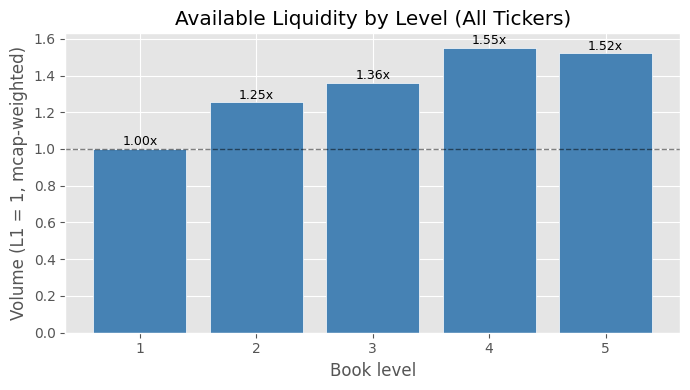

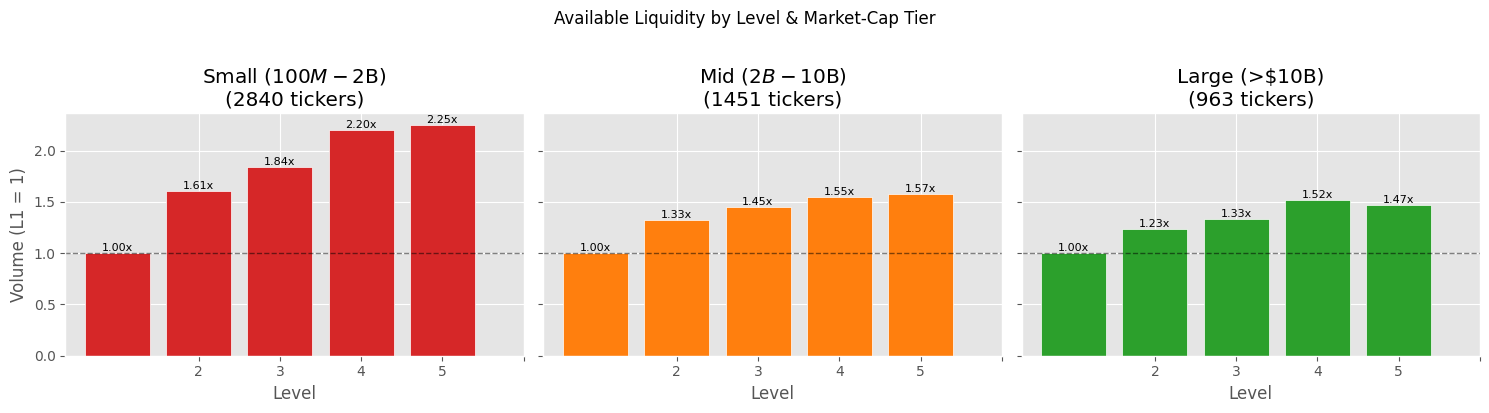

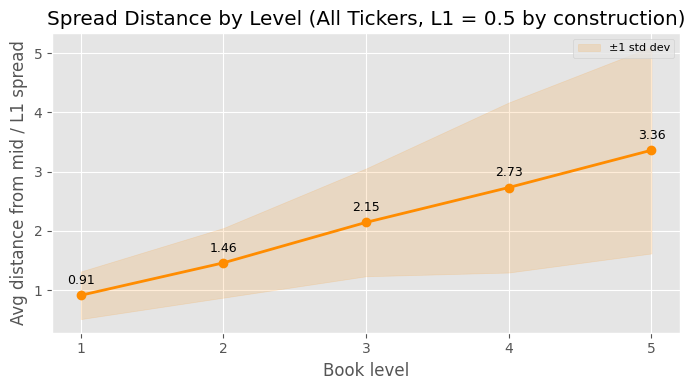

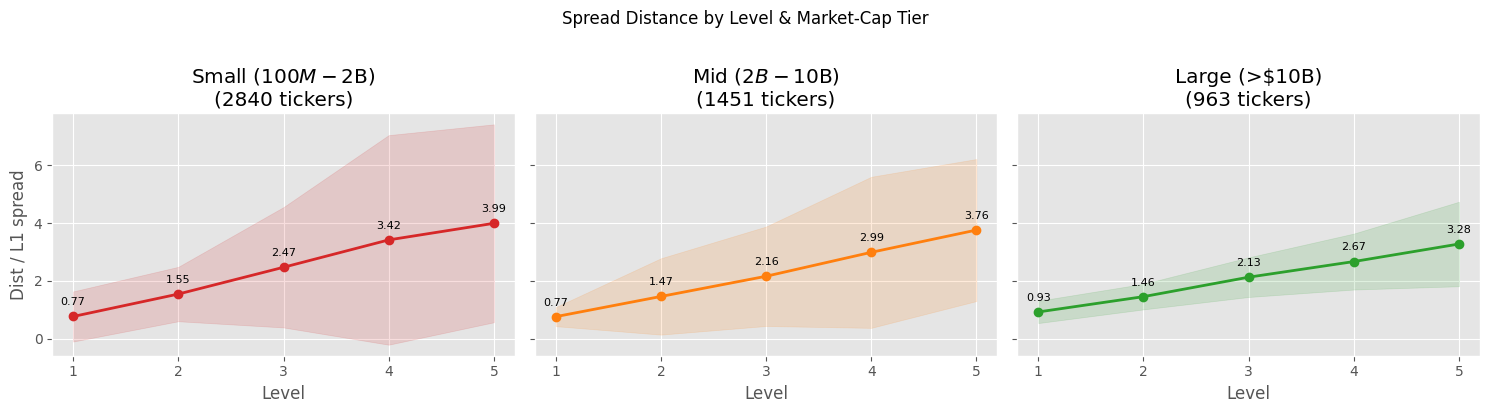

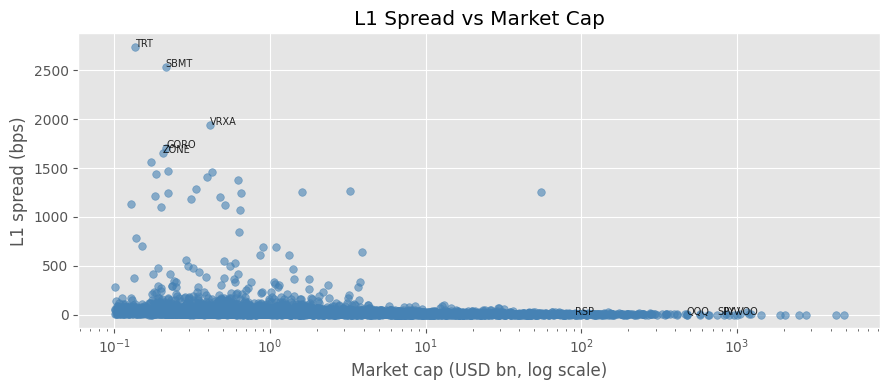

,Volume (x L1),Volume std dev,Dist / L1 spread,Dist std dev
Level,,,,
1,1.000,0.000,0.914,0.401
2,1.253,0.633,1.462,0.588
3,1.360,0.905,2.145,0.910
4,1.552,1.640,2.734,1.435
5,1.521,1.675,3.363,1.743



L1 spread (mcap-weighted):  avg = 7.94 bps  |  std = 37.57 bps
Universe: 5254 tickers  |  45965 listing-days


In [10]:
if tidy.empty:
    raise ValueError("No data. Run the batch and assemble cells first.")

# ── Universe filter: US | ADV > 1M | mcap > $100M | price > $1 ───────────────
meta = pd.read_csv(_csv_path)
meta["ticker"]    = meta["symbol"].str.replace(r"\.[A-Z]+$", "", regex=True)
meta["mcap_usd"]  = pd.to_numeric(meta["mktcapusd"], errors="coerce")
_adv_col          = next((c for c in meta.columns if c.lower() in ("adn20d", "adv", "advshares", "adv_shares")), None)
meta["adv_shares"] = pd.to_numeric(meta[_adv_col], errors="coerce")
_price_col        = next((c for c in meta.columns if c.lower() in ("price", "lastprice", "close", "closeprice")), None)
meta["price"]     = pd.to_numeric(meta[_price_col], errors="coerce") if _price_col else np.nan
meta = meta.dropna(subset=["ticker", "mcap_usd", "adv_shares"]).drop_duplicates("ticker")

us_tickers = (set(ref_unique.loc[ref_unique["MIC"].isin(US_MICS), "Ticker"].astype(str))
              if "MIC" in ref_unique.columns else set(listing_to_ticker.values()))

screen = meta[
    meta["ticker"].isin(us_tickers) &
    (meta["adv_shares"] > 1_000_000) &
    (meta["mcap_usd"]   > 100_000_000) &
    (meta["price"].isna() | (meta["price"] > 1))
].copy()

screen["cap_bin"] = pd.cut(
    screen["mcap_usd"],
    bins=[100e6, 2e9, 10e9, np.inf],
    labels=["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"],
    right=False,
)

allowed_lids = [lid for lid, tkr in listing_to_ticker.items() if tkr in set(screen["ticker"])]
df = (tidy[tidy["listing_id"].isin(allowed_lids)]
      .copy()
      .assign(ticker=lambda x: x["listing_id"].map(listing_to_ticker))
      .merge(screen[["ticker", "mcap_usd", "cap_bin"]], on="ticker", how="left")
      .dropna(subset=["mcap_usd", "cap_bin"]))

levels = sorted(df["level"].unique())

def wmean(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
    return np.average(v[mask], weights=w[mask]) if mask.any() else np.nan

def wstd(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if mask.sum() < 2:
        return np.nan
    mu = np.average(v[mask], weights=w[mask])
    return np.sqrt(np.average((v[mask] - mu) ** 2, weights=w[mask]))

# ── Per-stock summaries ───────────────────────────────────────────────────────
l1_vol = (df[df["level"] == 1][["listing_id", "date", "t", "norm_volume"]]
          .rename(columns={"norm_volume": "l1_vol"}))
dv = (df.merge(l1_vol, on=["listing_id", "date", "t"], how="left")
       .query("l1_vol > 0")
       .assign(vol_rel_l1=lambda x: x["norm_volume"] / x["l1_vol"]))

vol_ps  = dv.groupby(["listing_id", "level"]).agg(vol=("vol_rel_l1", "mean"), mcap=("mcap_usd", "first"), cap_bin=("cap_bin", "first")).reset_index()
nd_ps   = df.groupby(["listing_id", "level"]).agg(nd=("norm_dist",  "mean"), mcap=("mcap_usd", "first"), cap_bin=("cap_bin", "first")).reset_index()

vol_wtd = vol_ps.groupby("level").apply(lambda g: wmean(g["vol"], g["mcap"])).reindex(levels)
vol_std = vol_ps.groupby("level").apply(lambda g: wstd (g["vol"], g["mcap"])).reindex(levels)
nd_wtd  = nd_ps .groupby("level").apply(lambda g: wmean(g["nd"],  g["mcap"])).reindex(levels)
nd_std  = nd_ps .groupby("level").apply(lambda g: wstd (g["nd"],  g["mcap"])).reindex(levels)

# ── Chart 1: Overall volume by level ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(l) for l in levels], vol_wtd.values, color="steelblue", edgecolor="white")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
for lvl, val in zip(levels, vol_wtd.values):
    if np.isfinite(val):
        ax.text(str(lvl), val + 0.02, f"{val:.2f}x", ha="center", fontsize=9)
ax.set_xlabel("Book level"); ax.set_ylabel("Volume (L1 = 1, mcap-weighted)")
ax.set_title("Available Liquidity by Level (All Tickers)")
plt.tight_layout(); plt.show()

# ── Chart 1a-c: Volume by tier ───────────────────────────────────────────────
tier_order = ["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"]
tier_colors = ["#d62728", "#ff7f0e", "#2ca02c"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tier, color in zip(axes, tier_order, tier_colors):
    sub = vol_ps[vol_ps["cap_bin"] == tier]
    if sub.empty:
        ax.set_title(f"{tier}\n(no data)")
        continue
    vol_tier = sub.groupby("level").apply(lambda g: wmean(g["vol"], g["mcap"])).reindex(levels)
    ax.bar([str(l) for l in levels], vol_tier.values, color=color, edgecolor="white")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    for lvl, val in zip(levels, vol_tier.values):
        if np.isfinite(val):
            ax.text(str(lvl), val + 0.02, f"{val:.2f}x", ha="center", fontsize=8)
    ax.set_xticks(levels); ax.set_xlabel("Level")
    ax.set_title(f"{tier}\n({sub['listing_id'].nunique()} tickers)")
axes[0].set_ylabel("Volume (L1 = 1)")
fig.suptitle("Available Liquidity by Level & Market-Cap Tier", y=1.02)
plt.tight_layout(); plt.show()

# ── Chart 2: Overall distance from mid by level ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(levels, nd_wtd.values, marker="o", linewidth=2, color="darkorange")
ax.fill_between(levels,
                nd_wtd.values - nd_std.values,
                nd_wtd.values + nd_std.values,
                alpha=0.15, color="darkorange", label="±1 std dev")
for lvl, val in zip(levels, nd_wtd.values):
    if np.isfinite(val):
        ax.annotate(f"{val:.2f}", (lvl, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xticks(levels); ax.set_xlabel("Book level")
ax.set_ylabel("Avg distance from mid / L1 spread")
ax.set_title("Spread Distance by Level (All Tickers, L1 = 0.5 by construction)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Chart 2a-c: Distance by tier ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tier, color in zip(axes, tier_order, tier_colors):
    sub = nd_ps[nd_ps["cap_bin"] == tier]
    if sub.empty:
        ax.set_title(f"{tier}\n(no data)")
        continue
    nd_tier = sub.groupby("level").apply(lambda g: wmean(g["nd"], g["mcap"])).reindex(levels)
    nd_tier_std = sub.groupby("level").apply(lambda g: wstd(g["nd"], g["mcap"])).reindex(levels)
    ax.plot(levels, nd_tier.values, marker="o", linewidth=2, color=color)
    ax.fill_between(levels,
                    nd_tier.values - nd_tier_std.values,
                    nd_tier.values + nd_tier_std.values,
                    alpha=0.15, color=color)
    for lvl, val in zip(levels, nd_tier.values):
        if np.isfinite(val):
            ax.annotate(f"{val:.2f}", (lvl, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xticks(levels); ax.set_xlabel("Level")
    ax.set_title(f"{tier}\n({sub['listing_id'].nunique()} tickers)")
axes[0].set_ylabel("Dist / L1 spread")
fig.suptitle("Spread Distance by Level & Market-Cap Tier", y=1.02)
plt.tight_layout(); plt.show()

# ── Chart 3: L1 spread vs market cap ─────────────────────────────────────────
l1_df = (df[df["level"] == 1]
         .groupby("listing_id")
         .agg(spread_bps=("spread_bps", "mean"), mcap=("mcap_usd", "first"))
         .reset_index()
         .assign(ticker=lambda x: x["listing_id"].map(listing_to_ticker)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(l1_df["mcap"] / 1e9, l1_df["spread_bps"], alpha=0.6, s=30, color="steelblue")
for _, row in pd.concat([l1_df.nlargest(5, "spread_bps"), l1_df.nsmallest(5, "spread_bps")]).drop_duplicates("listing_id").iterrows():
    ax.annotate(row["ticker"], (row["mcap"] / 1e9, row["spread_bps"]), fontsize=7, alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Market cap (USD bn, log scale)"); ax.set_ylabel("L1 spread (bps)")
ax.set_title("L1 Spread vs Market Cap")
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Volume (x L1)":         vol_wtd.round(3),
    "Volume std dev":        vol_std.round(3),
    "Dist / L1 spread":      nd_wtd.round(3),
    "Dist std dev":          nd_std.round(3),
}, index=pd.Index(levels, name="Level"))

l1_spread_wtd = wmean(l1_df["spread_bps"], l1_df["mcap"])
l1_spread_std = wstd (l1_df["spread_bps"], l1_df["mcap"])

display(summary.style.format("{:.3f}").set_caption("Per-level summary (mcap-weighted)"))
print(f"\nL1 spread (mcap-weighted):  avg = {l1_spread_wtd:.2f} bps  |  std = {l1_spread_std:.2f} bps")
print(f"Universe: {l1_df['listing_id'].nunique()} tickers  |  {df[['listing_id','date']].drop_duplicates().shape[0]} listing-days")


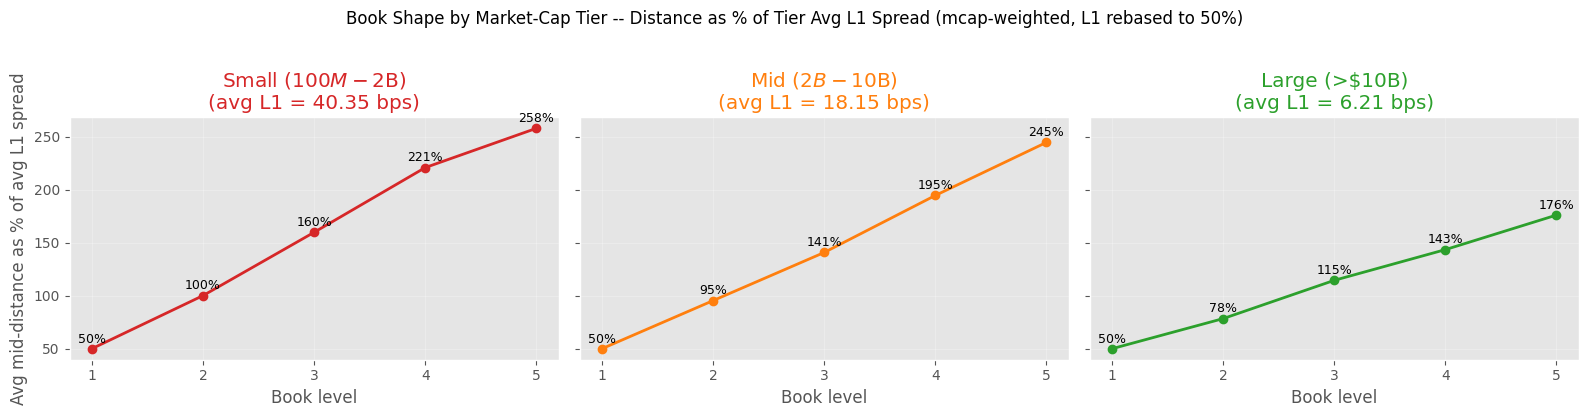

In [15]:
# Tier book-shape graph (no new runs; uses existing in-memory `df` only)
if "df" not in globals() or df.empty:
    raise RuntimeError("`df` is missing or empty. Run the existing analysis cells first, then run this cell.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def wmean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[mask], weights=weights[mask]) if mask.any() else np.nan


# Per-stock averages so each stock contributes once per level.
keep_cols = ["listing_id", "level", "norm_dist", "spread_bps", "mcap_usd"]
if "cap_bin" in df.columns:
    keep_cols.append("cap_bin")

ps = (
    df[keep_cols]
    .groupby(["listing_id", "level"], as_index=False)
    .agg(
        norm_dist=("norm_dist", "mean"),
        spread_bps=("spread_bps", "mean"),
        mcap_usd=("mcap_usd", "first"),
        cap_bin=("cap_bin", "first") if "cap_bin" in keep_cols else ("mcap_usd", "first"),
    )
    .dropna(subset=["mcap_usd"])
)

# Use your requested market-cap buckets.
if "cap_bin" not in df.columns:
    ps["cap_bin"] = pd.cut(
        ps["mcap_usd"],
        bins=[100e6, 2e9, 10e9, np.inf],
        labels=["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"],
        right=False,
    )

levels = sorted(ps["level"].dropna().astype(int).unique())
tier_order = ["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"]
tier_colors = {
    "Small ($100M-$2B)": "#d62728",
    "Mid ($2B-$10B)": "#ff7f0e",
    "Large (>$10B)": "#2ca02c",
}

# Build weighted series per tier/level, then rebase so L1 is exactly 50%.
rows = []
for tier in tier_order:
    sub = ps[ps["cap_bin"].astype(str) == tier]
    l1_sub = sub[sub["level"] == 1]
    avg_l1_bps = wmean(l1_sub["spread_bps"], l1_sub["mcap_usd"]) if not l1_sub.empty else np.nan

    raw_pct = {}
    for lvl in levels:
        g = sub[sub["level"] == lvl]
        raw_pct[lvl] = wmean(g["norm_dist"], g["mcap_usd"]) * 100 if not g.empty else np.nan

    l1_raw = raw_pct.get(1, np.nan)
    scale = 50.0 / l1_raw if np.isfinite(l1_raw) and l1_raw > 0 else np.nan

    for lvl in levels:
        pct_rebased = raw_pct[lvl] * scale if np.isfinite(scale) and np.isfinite(raw_pct[lvl]) else np.nan
        rows.append({
            "tier": tier,
            "level": int(lvl),
            "pct": pct_rebased,
            "avg_l1_bps": avg_l1_bps,
        })

plot_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle("Book Shape by Market-Cap Tier -- Distance as % of Tier Avg L1 Spread (mcap-weighted, L1 rebased to 50%)", y=1.03)

for ax, tier in zip(axes, tier_order):
    sub = plot_df[plot_df["tier"] == tier].sort_values("level")
    color = tier_colors[tier]
    avg_l1 = sub["avg_l1_bps"].dropna().iloc[0] if sub["avg_l1_bps"].notna().any() else np.nan

    ax.plot(sub["level"], sub["pct"], marker="o", linewidth=2, color=color)

    for _, r in sub.iterrows():
        if np.isfinite(r["pct"]):
            ax.text(r["level"], r["pct"] + 3, f"{r['pct']:.0f}%", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(levels)
    ax.set_xlabel("Book level")
    title = f"{tier}\n(avg L1 = {avg_l1:.2f} bps)" if np.isfinite(avg_l1) else f"{tier}\n(avg L1 = n/a)"
    ax.set_title(title, color=color)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Avg mid-distance as % of avg L1 spread")
plt.tight_layout()
plt.show()

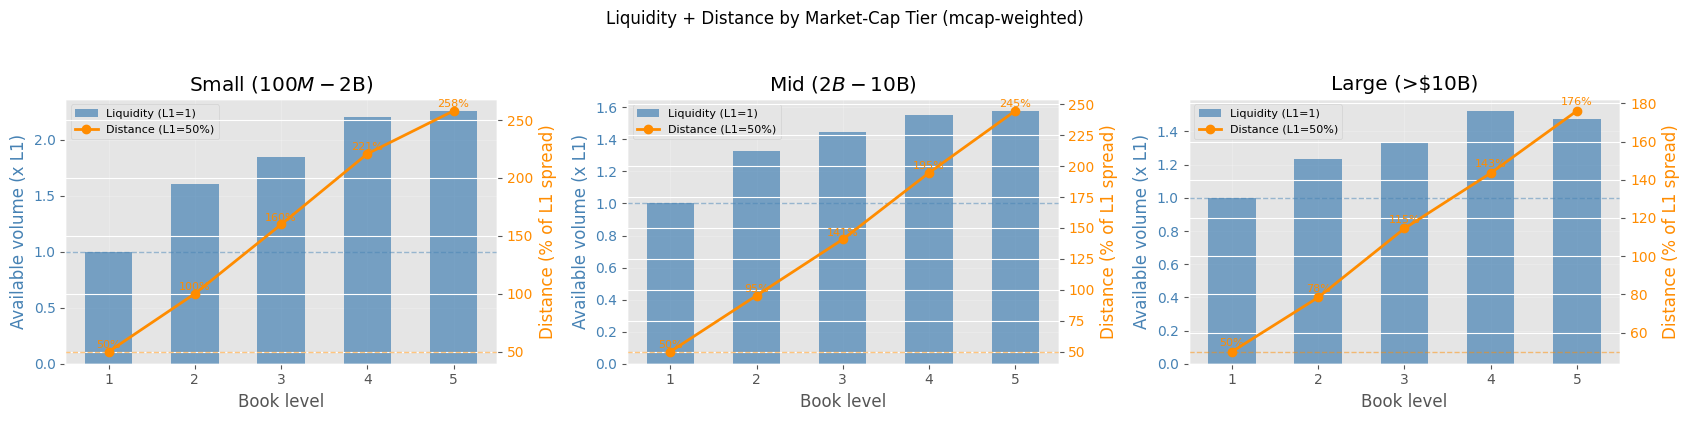

In [17]:
# Combined chart: size (bars) + distance (line) by market-cap tier
# Uses existing in-memory `df` only (no new data runs).
if "df" not in globals() or df.empty:
    raise RuntimeError("`df` is missing or empty. Run the existing analysis cells first, then run this cell.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def wmean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[mask], weights=weights[mask]) if mask.any() else np.nan


# Ensure we have the requested market-cap tiers.
if "cap_bin" in df.columns:
    work = df.copy()
else:
    work = df.copy()
    work["cap_bin"] = pd.cut(
        work["mcap_usd"],
        bins=[100e6, 2e9, 10e9, np.inf],
        labels=["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"],
        right=False,
    )

# --- Liquidity: use EXACT same methodology as the bar plots above ---
# Per snapshot, normalize by that snapshot's L1, then average per stock+level.
l1_vol = (
    work[work["level"] == 1][["listing_id", "date", "t", "norm_volume"]]
    .rename(columns={"norm_volume": "l1_vol"})
)

dv = (
    work.merge(l1_vol, on=["listing_id", "date", "t"], how="left")
    .query("l1_vol > 0")
    .assign(vol_rel_l1=lambda x: x["norm_volume"] / x["l1_vol"])
)

vol_ps = (
    dv.groupby(["listing_id", "level"], as_index=False)
    .agg(
        vol=("vol_rel_l1", "mean"),
        mcap_usd=("mcap_usd", "first"),
        cap_bin=("cap_bin", "first"),
    )
)

# --- Distance: same per-stock averaging logic as above ---
nd_ps = (
    work.groupby(["listing_id", "level"], as_index=False)
    .agg(
        nd=("norm_dist", "mean"),
        mcap_usd=("mcap_usd", "first"),
        cap_bin=("cap_bin", "first"),
    )
)

levels = sorted(work["level"].dropna().astype(int).unique())
tier_order = ["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharex=True)
fig.suptitle("Liquidity + Distance by Market-Cap Tier (mcap-weighted)", y=1.04)

for ax, tier in zip(axes, tier_order):
    vol_sub = vol_ps[vol_ps["cap_bin"].astype(str) == tier]
    nd_sub = nd_ps[nd_ps["cap_bin"].astype(str) == tier]

    # mcap-weighted by level (same as prior tier bar/line logic).
    liq_raw = vol_sub.groupby("level").apply(lambda g: wmean(g["vol"], g["mcap_usd"]))
    dist_raw = nd_sub.groupby("level").apply(lambda g: wmean(g["nd"], g["mcap_usd"])) * 100

    # Reindex to full level set.
    liq_raw = liq_raw.reindex(levels)
    dist_raw = dist_raw.reindex(levels)

    # Keep bar scale identical to earlier bar plots (L1=1 by construction of vol_rel_l1).
    liq = liq_raw.values.astype(float)

    # Rebase distance so L1 is exactly 50% for comparability.
    l1_dist = dist_raw.loc[1] if 1 in dist_raw.index else np.nan
    dist_scale = 50.0 / l1_dist if np.isfinite(l1_dist) and l1_dist > 0 else np.nan
    dist = (dist_raw * dist_scale).values.astype(float) if np.isfinite(dist_scale) else dist_raw.values.astype(float)

    # Bars for liquidity.
    ax.bar(levels, liq, color="steelblue", alpha=0.7, width=0.55, label="Liquidity (L1=1)")
    ax.axhline(1.0, color="steelblue", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Book level")
    ax.set_xticks(levels)
    ax.set_ylabel("Available volume (x L1)", color="steelblue")
    ax.tick_params(axis="y", labelcolor="steelblue")

    # Line for distance on secondary axis.
    ax2 = ax.twinx()
    ax2.plot(levels, dist, marker="o", linewidth=2, color="darkorange", label="Distance (L1=50%)")
    ax2.axhline(50, color="darkorange", linestyle="--", linewidth=1, alpha=0.5)
    ax2.set_ylabel("Distance (% of L1 spread)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    for x, y in zip(levels, dist):
        if np.isfinite(y):
            ax2.text(x, y + 3, f"{y:.0f}%", ha="center", fontsize=8, color="darkorange")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)

    ax.set_title(tier)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

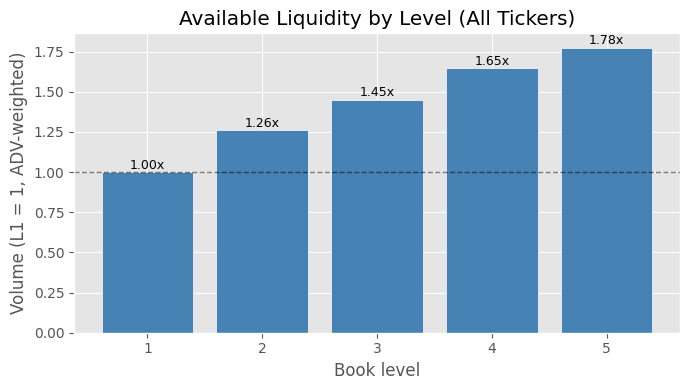

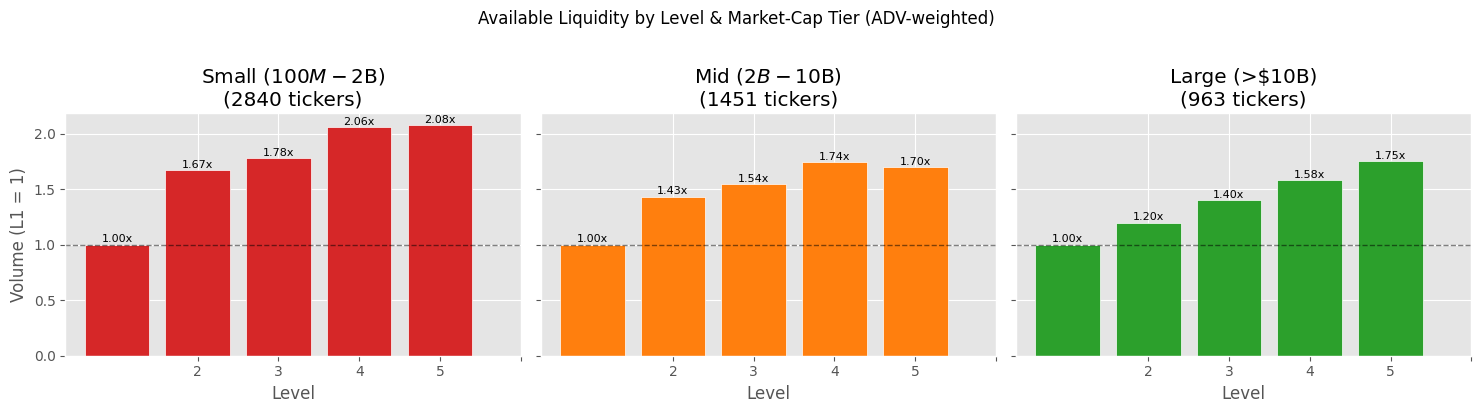

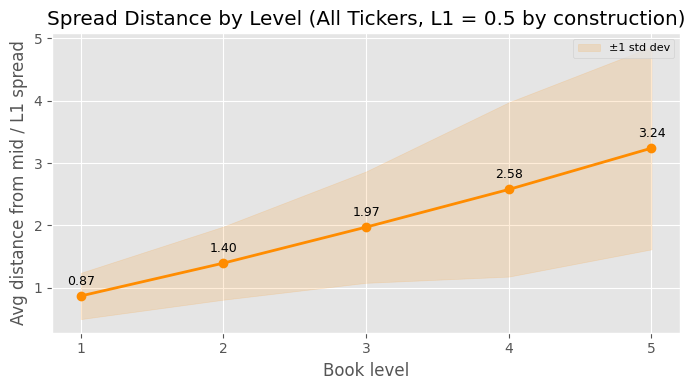

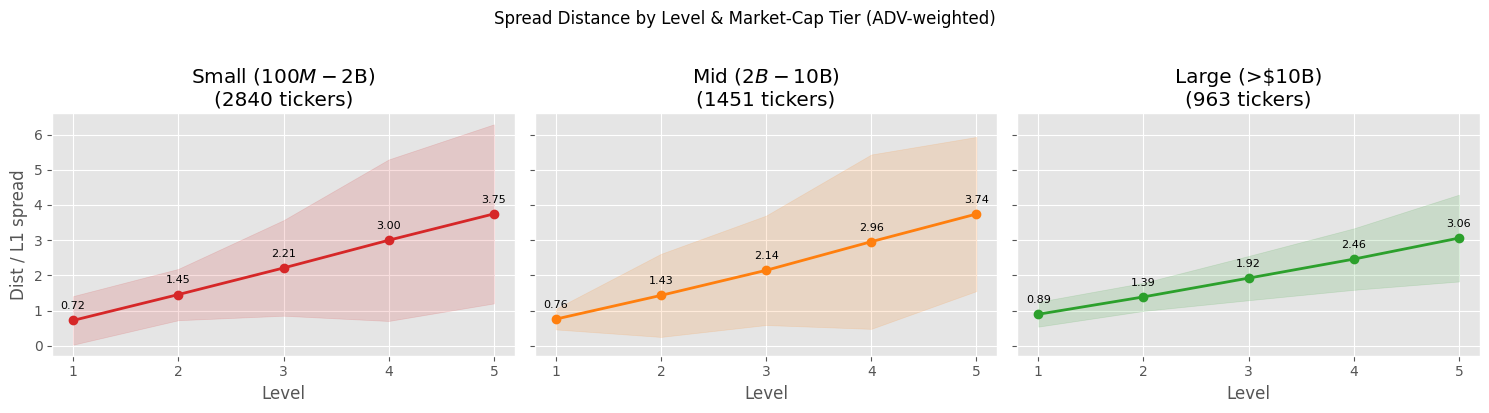

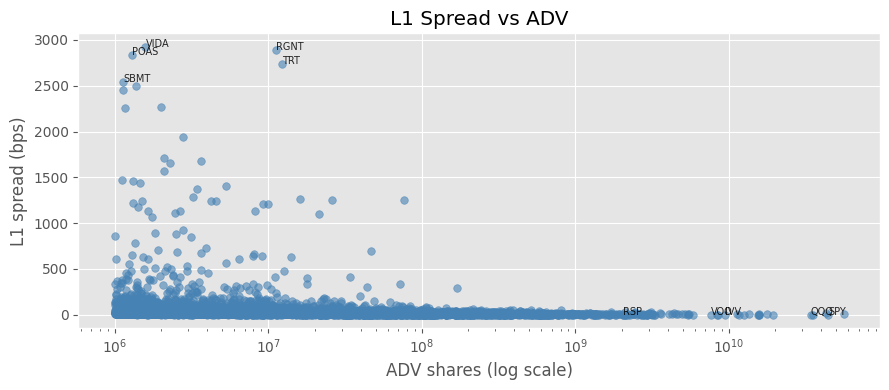

,Volume (x L1),Volume std dev,Dist / L1 spread,Dist std dev
Level,,,,
1,1.000,0.000,0.869,0.371
2,1.259,0.775,1.396,0.586
3,1.451,0.995,1.973,0.892
4,1.647,1.889,2.576,1.397
5,1.775,1.721,3.238,1.622



L1 spread (ADV-weighted): avg = 8.81 bps | std = 28.75 bps
Universe: 5693 tickers | 50127 listing-days


In [23]:
# ADV-weighted chart set (same structure as above, no new data pulls)
if "tidy" not in globals() or tidy.empty:
    raise ValueError("No data. Run the batch and assemble cells first.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build ticker metadata with ADV from source CSV (column D / adv field family).
meta_adv = pd.read_csv(_csv_path)
meta_adv["ticker"] = meta_adv["symbol"].str.replace(r"\.[A-Z]+$", "", regex=True)
_adv_col_local = next((c for c in meta_adv.columns if c.lower() in ("adn20d", "adv", "advshares", "adv_shares")), None)
if _adv_col_local is None:
    raise ValueError("Could not find ADV column in source CSV (expected one of: adn20d, adv, advshares, adv_shares)")

meta_adv["adv_shares"] = pd.to_numeric(meta_adv[_adv_col_local], errors="coerce")
meta_adv["mcap_usd"] = pd.to_numeric(meta_adv.get("mktcapusd", np.nan), errors="coerce")
meta_adv = meta_adv.dropna(subset=["ticker", "adv_shares"]).drop_duplicates("ticker")

# Keep same universe logic and same tier labels as above for consistency.
us_tickers_adv = (
    set(ref_unique.loc[ref_unique["MIC"].isin(US_MICS), "Ticker"].astype(str))
    if "MIC" in ref_unique.columns
    else set(listing_to_ticker.values())
)

screen_adv = meta_adv[
    meta_adv["ticker"].isin(us_tickers_adv) &
    (meta_adv["adv_shares"] > 1_000_000)
].copy()

# Keep familiar Small/Mid/Large labels using mcap cut if available; fallback to Unknown.
if screen_adv["mcap_usd"].notna().any():
    screen_adv["cap_bin"] = pd.cut(
        screen_adv["mcap_usd"],
        bins=[100e6, 2e9, 10e9, np.inf],
        labels=["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"],
        right=False,
    )
else:
    screen_adv["cap_bin"] = "Unknown"

allowed_lids_adv = [lid for lid, tkr in listing_to_ticker.items() if tkr in set(screen_adv["ticker"])]

df_adv = (
    tidy[tidy["listing_id"].isin(allowed_lids_adv)]
    .copy()
    .assign(ticker=lambda x: x["listing_id"].map(listing_to_ticker))
    .merge(screen_adv[["ticker", "adv_shares", "cap_bin"]], on="ticker", how="left")
    .dropna(subset=["adv_shares"])
)

if df_adv.empty:
    raise ValueError("No rows after ADV merge/filter. Check ADV column and prior steps.")

levels_adv = sorted(df_adv["level"].dropna().astype(int).unique())


def wmean(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
    return np.average(v[mask], weights=w[mask]) if mask.any() else np.nan


def wstd(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if mask.sum() < 2:
        return np.nan
    mu = np.average(v[mask], weights=w[mask])
    return np.sqrt(np.average((v[mask] - mu) ** 2, weights=w[mask]))


# Per-stock summaries with ADV weights.
l1_vol_adv = (
    df_adv[df_adv["level"] == 1][["listing_id", "date", "t", "norm_volume"]]
    .rename(columns={"norm_volume": "l1_vol"})
)
dv_adv = (
    df_adv.merge(l1_vol_adv, on=["listing_id", "date", "t"], how="left")
    .query("l1_vol > 0")
    .assign(vol_rel_l1=lambda x: x["norm_volume"] / x["l1_vol"])
)

vol_ps_adv = dv_adv.groupby(["listing_id", "level"]).agg(
    vol=("vol_rel_l1", "mean"),
    adv=("adv_shares", "first"),
    cap_bin=("cap_bin", "first"),
).reset_index()

nd_ps_adv = df_adv.groupby(["listing_id", "level"]).agg(
    nd=("norm_dist", "mean"),
    adv=("adv_shares", "first"),
    cap_bin=("cap_bin", "first"),
).reset_index()

vol_wtd_adv = vol_ps_adv.groupby("level").apply(lambda g: wmean(g["vol"], g["adv"])).reindex(levels_adv)
vol_std_adv = vol_ps_adv.groupby("level").apply(lambda g: wstd(g["vol"], g["adv"])).reindex(levels_adv)
nd_wtd_adv = nd_ps_adv.groupby("level").apply(lambda g: wmean(g["nd"], g["adv"])).reindex(levels_adv)
nd_std_adv = nd_ps_adv.groupby("level").apply(lambda g: wstd(g["nd"], g["adv"])).reindex(levels_adv)

# Chart 1: Overall volume by level (ADV-weighted)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(l) for l in levels_adv], vol_wtd_adv.values, color="steelblue", edgecolor="white")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
for lvl, val in zip(levels_adv, vol_wtd_adv.values):
    if np.isfinite(val):
        ax.text(str(lvl), val + 0.02, f"{val:.2f}x", ha="center", fontsize=9)
ax.set_xlabel("Book level")
ax.set_ylabel("Volume (L1 = 1, ADV-weighted)")
ax.set_title("Available Liquidity by Level (All Tickers)")
plt.tight_layout(); plt.show()

# Chart 1a-c: Volume by tier (ADV-weighted)
tier_order_adv = ["Small ($100M-$2B)", "Mid ($2B-$10B)", "Large (>$10B)"]
tier_colors_adv = ["#d62728", "#ff7f0e", "#2ca02c"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tier, color in zip(axes, tier_order_adv, tier_colors_adv):
    sub = vol_ps_adv[vol_ps_adv["cap_bin"].astype(str) == tier]
    if sub.empty:
        ax.set_title(f"{tier}\n(no data)")
        continue
    vol_tier = sub.groupby("level").apply(lambda g: wmean(g["vol"], g["adv"])).reindex(levels_adv)
    ax.bar([str(l) for l in levels_adv], vol_tier.values, color=color, edgecolor="white")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    for lvl, val in zip(levels_adv, vol_tier.values):
        if np.isfinite(val):
            ax.text(str(lvl), val + 0.02, f"{val:.2f}x", ha="center", fontsize=8)
    ax.set_xticks(levels_adv)
    ax.set_xlabel("Level")
    ax.set_title(f"{tier}\n({sub['listing_id'].nunique()} tickers)")
axes[0].set_ylabel("Volume (L1 = 1)")
fig.suptitle("Available Liquidity by Level & Market-Cap Tier (ADV-weighted)", y=1.02)
plt.tight_layout(); plt.show()

# Chart 2: Overall distance from mid by level (ADV-weighted)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(levels_adv, nd_wtd_adv.values, marker="o", linewidth=2, color="darkorange")
ax.fill_between(
    levels_adv,
    nd_wtd_adv.values - nd_std_adv.values,
    nd_wtd_adv.values + nd_std_adv.values,
    alpha=0.15,
    color="darkorange",
    label="±1 std dev",
)
for lvl, val in zip(levels_adv, nd_wtd_adv.values):
    if np.isfinite(val):
        ax.annotate(f"{val:.2f}", (lvl, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xticks(levels_adv)
ax.set_xlabel("Book level")
ax.set_ylabel("Avg distance from mid / L1 spread")
ax.set_title("Spread Distance by Level (All Tickers, L1 = 0.5 by construction)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Chart 2a-c: Distance by tier (ADV-weighted)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tier, color in zip(axes, tier_order_adv, tier_colors_adv):
    sub = nd_ps_adv[nd_ps_adv["cap_bin"].astype(str) == tier]
    if sub.empty:
        ax.set_title(f"{tier}\n(no data)")
        continue
    nd_tier = sub.groupby("level").apply(lambda g: wmean(g["nd"], g["adv"])).reindex(levels_adv)
    nd_tier_std = sub.groupby("level").apply(lambda g: wstd(g["nd"], g["adv"])).reindex(levels_adv)
    ax.plot(levels_adv, nd_tier.values, marker="o", linewidth=2, color=color)
    ax.fill_between(levels_adv, nd_tier.values - nd_tier_std.values, nd_tier.values + nd_tier_std.values, alpha=0.15, color=color)
    for lvl, val in zip(levels_adv, nd_tier.values):
        if np.isfinite(val):
            ax.annotate(f"{val:.2f}", (lvl, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xticks(levels_adv)
    ax.set_xlabel("Level")
    ax.set_title(f"{tier}\n({sub['listing_id'].nunique()} tickers)")
axes[0].set_ylabel("Dist / L1 spread")
fig.suptitle("Spread Distance by Level & Market-Cap Tier (ADV-weighted)", y=1.02)
plt.tight_layout(); plt.show()

# Chart 3: L1 spread vs ADV
l1_df_adv = (
    df_adv[df_adv["level"] == 1]
    .groupby("listing_id")
    .agg(spread_bps=("spread_bps", "mean"), adv=("adv_shares", "first"))
    .reset_index()
    .assign(ticker=lambda x: x["listing_id"].map(listing_to_ticker))
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(l1_df_adv["adv"], l1_df_adv["spread_bps"], alpha=0.6, s=30, color="steelblue")
for _, row in pd.concat([l1_df_adv.nlargest(5, "spread_bps"), l1_df_adv.nsmallest(5, "spread_bps")]).drop_duplicates("listing_id").iterrows():
    ax.annotate(row["ticker"], (row["adv"], row["spread_bps"]), fontsize=7, alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("ADV shares (log scale)")
ax.set_ylabel("L1 spread (bps)")
ax.set_title("L1 Spread vs ADV")
plt.tight_layout(); plt.show()

# Summary table (ADV-weighted)
summary_adv = pd.DataFrame({
    "Volume (x L1)": vol_wtd_adv.round(3),
    "Volume std dev": vol_std_adv.round(3),
    "Dist / L1 spread": nd_wtd_adv.round(3),
    "Dist std dev": nd_std_adv.round(3),
}, index=pd.Index(levels_adv, name="Level"))

l1_spread_wtd_adv = wmean(l1_df_adv["spread_bps"], l1_df_adv["adv"])
l1_spread_std_adv = wstd(l1_df_adv["spread_bps"], l1_df_adv["adv"])

display(summary_adv.style.format("{:.3f}").set_caption("Per-level summary (ADV-weighted)"))
print(f"\nL1 spread (ADV-weighted): avg = {l1_spread_wtd_adv:.2f} bps | std = {l1_spread_std_adv:.2f} bps")
print(f"Universe: {l1_df_adv['listing_id'].nunique()} tickers | {df_adv[['listing_id','date']].drop_duplicates().shape[0]} listing-days")

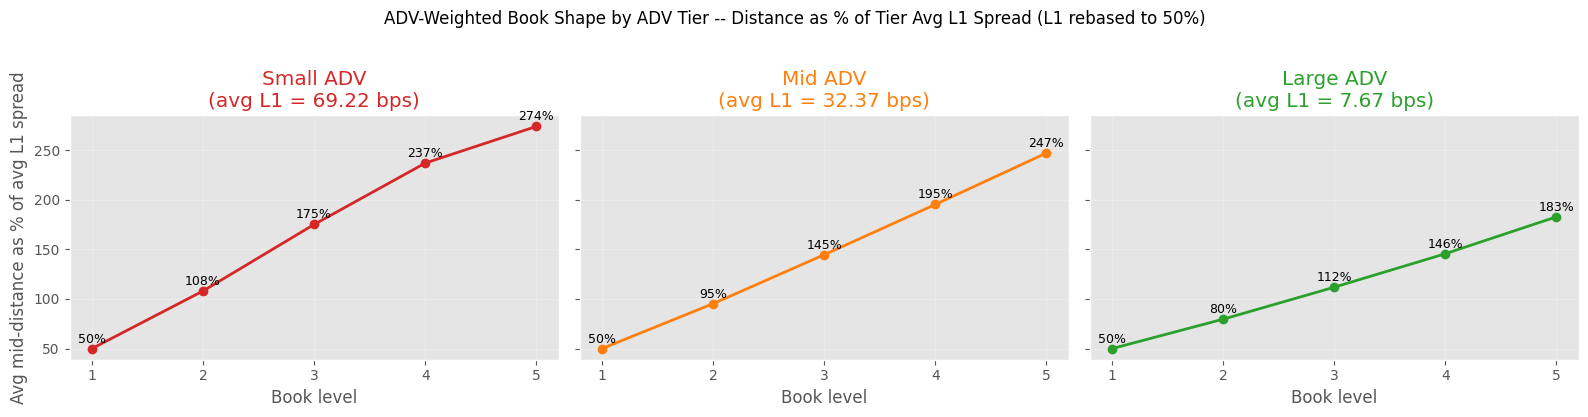

In [22]:
# ADV version of Cell 10: tier distance graph (L1 rebased to 50%)
# Uses existing in-memory data only, with ADV-only weighting and ADV-only tiers.
if "tidy" not in globals() or tidy.empty:
    raise ValueError("No data. Run the batch and assemble cells first.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

meta_adv = pd.read_csv(_csv_path)
meta_adv["ticker"] = meta_adv["symbol"].str.replace(r"\.[A-Z]+$", "", regex=True)
_adv_col_local = next((c for c in meta_adv.columns if c.lower() in ("adn20d", "adv", "advshares", "adv_shares")), None)
if _adv_col_local is None:
    raise ValueError("Could not find ADV column in source CSV.")
meta_adv["adv_shares"] = pd.to_numeric(meta_adv[_adv_col_local], errors="coerce")
meta_adv = meta_adv.dropna(subset=["ticker", "adv_shares"]).drop_duplicates("ticker")

us_tickers_adv = (
    set(ref_unique.loc[ref_unique["MIC"].isin(US_MICS), "Ticker"].astype(str))
    if "MIC" in ref_unique.columns
    else set(listing_to_ticker.values())
)

screen_adv = meta_adv[
    meta_adv["ticker"].isin(us_tickers_adv) &
    (meta_adv["adv_shares"] > 1_000_000)
].copy()

# ADV-only tiering: terciles -> Small/Mid/Large by ADV.
screen_adv["adv_bin"] = pd.qcut(
    screen_adv["adv_shares"],
    q=3,
    labels=["Small ADV", "Mid ADV", "Large ADV"],
    duplicates="drop",
)

allowed_lids_adv = [lid for lid, tkr in listing_to_ticker.items() if tkr in set(screen_adv["ticker"])]
df_adv = (
    tidy[tidy["listing_id"].isin(allowed_lids_adv)]
    .copy()
    .assign(ticker=lambda x: x["listing_id"].map(listing_to_ticker))
    .merge(screen_adv[["ticker", "adv_shares", "adv_bin"]], on="ticker", how="left")
    .dropna(subset=["adv_shares", "adv_bin"])
)

if df_adv.empty:
    raise ValueError("No rows after ADV merge/filter.")


def wmean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[mask], weights=weights[mask]) if mask.any() else np.nan

ps_adv = (
    df_adv.groupby(["listing_id", "level"], as_index=False)
    .agg(
        norm_dist=("norm_dist", "mean"),
        spread_bps=("spread_bps", "mean"),
        adv=("adv_shares", "first"),
        adv_bin=("adv_bin", "first"),
    )
)

levels_adv = sorted(ps_adv["level"].dropna().astype(int).unique())
tier_order_adv = ["Small ADV", "Mid ADV", "Large ADV"]
tier_colors_adv = {
    "Small ADV": "#d62728",
    "Mid ADV": "#ff7f0e",
    "Large ADV": "#2ca02c",
}

rows = []
for tier in tier_order_adv:
    sub = ps_adv[ps_adv["adv_bin"].astype(str) == tier]
    l1_sub = sub[sub["level"] == 1]
    avg_l1_bps = wmean(l1_sub["spread_bps"], l1_sub["adv"]) if not l1_sub.empty else np.nan

    raw_pct = {}
    for lvl in levels_adv:
        g = sub[sub["level"] == lvl]
        raw_pct[lvl] = wmean(g["norm_dist"], g["adv"]) * 100 if not g.empty else np.nan

    l1_raw = raw_pct.get(1, np.nan)
    scale = 50.0 / l1_raw if np.isfinite(l1_raw) and l1_raw > 0 else np.nan

    for lvl in levels_adv:
        pct_rebased = raw_pct[lvl] * scale if np.isfinite(scale) and np.isfinite(raw_pct[lvl]) else np.nan
        rows.append({
            "tier": tier,
            "level": int(lvl),
            "pct": pct_rebased,
            "avg_l1_bps": avg_l1_bps,
        })

plot_df_adv = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle("ADV-Weighted Book Shape by ADV Tier -- Distance as % of Tier Avg L1 Spread (L1 rebased to 50%)", y=1.03)

for ax, tier in zip(axes, tier_order_adv):
    sub = plot_df_adv[plot_df_adv["tier"] == tier].sort_values("level")
    color = tier_colors_adv[tier]
    avg_l1 = sub["avg_l1_bps"].dropna().iloc[0] if sub["avg_l1_bps"].notna().any() else np.nan

    ax.plot(sub["level"], sub["pct"], marker="o", linewidth=2, color=color)
    for _, r in sub.iterrows():
        if np.isfinite(r["pct"]):
            ax.text(r["level"], r["pct"] + 3, f"{r['pct']:.0f}%", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(levels_adv)
    ax.set_xlabel("Book level")
    title = f"{tier}\n(avg L1 = {avg_l1:.2f} bps)" if np.isfinite(avg_l1) else f"{tier}\n(avg L1 = n/a)"
    ax.set_title(title, color=color)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Avg mid-distance as % of avg L1 spread")
plt.tight_layout(); plt.show()

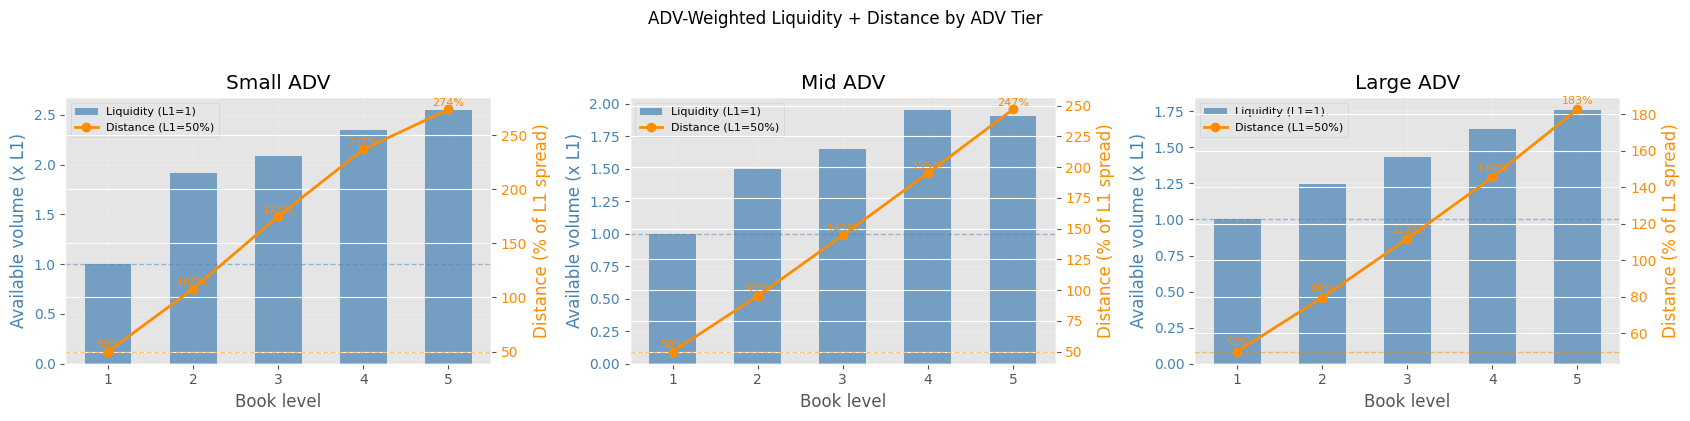

In [21]:
# ADV version of Cell 11: combined bars (liquidity) + line (distance)
# Uses existing in-memory data only, with ADV-only weighting and ADV-only tiers.
if "tidy" not in globals() or tidy.empty:
    raise ValueError("No data. Run the batch and assemble cells first.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

meta_adv = pd.read_csv(_csv_path)
meta_adv["ticker"] = meta_adv["symbol"].str.replace(r"\.[A-Z]+$", "", regex=True)
_adv_col_local = next((c for c in meta_adv.columns if c.lower() in ("adn20d", "adv", "advshares", "adv_shares")), None)
if _adv_col_local is None:
    raise ValueError("Could not find ADV column in source CSV.")
meta_adv["adv_shares"] = pd.to_numeric(meta_adv[_adv_col_local], errors="coerce")
meta_adv = meta_adv.dropna(subset=["ticker", "adv_shares"]).drop_duplicates("ticker")

us_tickers_adv = (
    set(ref_unique.loc[ref_unique["MIC"].isin(US_MICS), "Ticker"].astype(str))
    if "MIC" in ref_unique.columns
    else set(listing_to_ticker.values())
)

screen_adv = meta_adv[
    meta_adv["ticker"].isin(us_tickers_adv) &
    (meta_adv["adv_shares"] > 1_000_000)
].copy()

# ADV-only tiering: terciles -> Small/Mid/Large by ADV.
screen_adv["adv_bin"] = pd.qcut(
    screen_adv["adv_shares"],
    q=3,
    labels=["Small ADV", "Mid ADV", "Large ADV"],
    duplicates="drop",
)

allowed_lids_adv = [lid for lid, tkr in listing_to_ticker.items() if tkr in set(screen_adv["ticker"])]
df_adv = (
    tidy[tidy["listing_id"].isin(allowed_lids_adv)]
    .copy()
    .assign(ticker=lambda x: x["listing_id"].map(listing_to_ticker))
    .merge(screen_adv[["ticker", "adv_shares", "adv_bin"]], on="ticker", how="left")
    .dropna(subset=["adv_shares", "adv_bin"])
)

if df_adv.empty:
    raise ValueError("No rows after ADV merge/filter.")


def wmean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[mask], weights=weights[mask]) if mask.any() else np.nan

# Liquidity: same method, ADV weights.
l1_vol_adv = (
    df_adv[df_adv["level"] == 1][["listing_id", "date", "t", "norm_volume"]]
    .rename(columns={"norm_volume": "l1_vol"})
)
dv_adv = (
    df_adv.merge(l1_vol_adv, on=["listing_id", "date", "t"], how="left")
    .query("l1_vol > 0")
    .assign(vol_rel_l1=lambda x: x["norm_volume"] / x["l1_vol"])
)

vol_ps_adv = dv_adv.groupby(["listing_id", "level"], as_index=False).agg(
    vol=("vol_rel_l1", "mean"),
    adv=("adv_shares", "first"),
    adv_bin=("adv_bin", "first"),
)

nd_ps_adv = df_adv.groupby(["listing_id", "level"], as_index=False).agg(
    nd=("norm_dist", "mean"),
    adv=("adv_shares", "first"),
    adv_bin=("adv_bin", "first"),
)

levels_adv = sorted(df_adv["level"].dropna().astype(int).unique())
tier_order_adv = ["Small ADV", "Mid ADV", "Large ADV"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharex=True)
fig.suptitle("ADV-Weighted Liquidity + Distance by ADV Tier", y=1.04)

for ax, tier in zip(axes, tier_order_adv):
    vol_sub = vol_ps_adv[vol_ps_adv["adv_bin"].astype(str) == tier]
    nd_sub = nd_ps_adv[nd_ps_adv["adv_bin"].astype(str) == tier]

    liq_raw = vol_sub.groupby("level").apply(lambda g: wmean(g["vol"], g["adv"]))
    dist_raw = nd_sub.groupby("level").apply(lambda g: wmean(g["nd"], g["adv"])) * 100

    liq_raw = liq_raw.reindex(levels_adv)
    dist_raw = dist_raw.reindex(levels_adv)

    liq = liq_raw.values.astype(float)
    l1_dist = dist_raw.loc[1] if 1 in dist_raw.index else np.nan
    dist_scale = 50.0 / l1_dist if np.isfinite(l1_dist) and l1_dist > 0 else np.nan
    dist = (dist_raw * dist_scale).values.astype(float) if np.isfinite(dist_scale) else dist_raw.values.astype(float)

    ax.bar(levels_adv, liq, color="steelblue", alpha=0.7, width=0.55, label="Liquidity (L1=1)")
    ax.axhline(1.0, color="steelblue", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Book level")
    ax.set_xticks(levels_adv)
    ax.set_ylabel("Available volume (x L1)", color="steelblue")
    ax.tick_params(axis="y", labelcolor="steelblue")

    ax2 = ax.twinx()
    ax2.plot(levels_adv, dist, marker="o", linewidth=2, color="darkorange", label="Distance (L1=50%)")
    ax2.axhline(50, color="darkorange", linestyle="--", linewidth=1, alpha=0.5)
    ax2.set_ylabel("Distance (% of L1 spread)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    for x, y in zip(levels_adv, dist):
        if np.isfinite(y):
            ax2.text(x, y + 3, f"{y:.0f}%", ha="center", fontsize=8, color="darkorange")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)

    ax.set_title(tier)
    ax.grid(alpha=0.2)

plt.tight_layout(); plt.show()

usage: ipykernel_launcher.py [-h] [--outdir OUTDIR] notebook
ipykernel_launcher.py: error: unrecognized arguments: -f


SystemExit: 2

/home/bmll/.conda/envs/py311-stable/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3561: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.

